In [1]:
from sklearn.datasets import make_regression

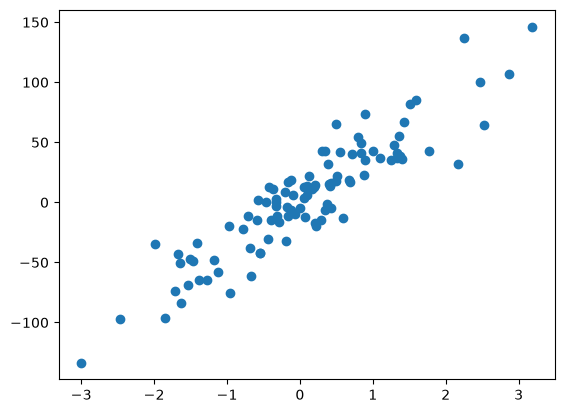

In [2]:
X,Y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20)
plt.scatter(X,Y)

In [5]:
lr = LinearRegression()
lr.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[38.76]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.009
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[11.34]


In [6]:
lr.coef_

array([38.75874901])

In [7]:
lr.intercept_

np.float64(1.008867915837682)

In [8]:
m = 38.75

In [9]:
class custom_GD:
    def __init__(self,learning_rate,epochs):
        self.m = 38.75
        self.b = -120
        self.rate = learning_rate
        self.epochs = epochs

    def fit(self,X,Y):
        #calculate b using gradient descent
        for i in range(self.epochs):
            loss_slope = -2 * np.sum(Y-self.m*X.ravel() - self.b)
            self.b = self.b - (self.rate * loss_slope)
            print(loss_slope,self.b)
        print(self.b)

In [10]:
gd = custom_GD(0.001,100)


In [11]:
gd.fit(X,Y)


-24201.93840797685 -95.79806159202315
-19361.550726381476 -76.43651086564167
-15489.240581105187 -60.94727028453648
-12391.392464884148 -48.55587781965233
-9913.113971907318 -38.642763847745016
-7930.491177525854 -30.71227267021916
-6344.392942020684 -24.367879728198474
-5075.514353616547 -19.292365374581927
-4060.4114828932375 -15.23195389168869
-3248.32918631459 -11.9836247053741
-2598.6633490516715 -9.384961356322428
-2078.9306792413377 -7.3060306770810906
-1663.14454339307 -5.6428861336880205
-1330.5156347144562 -4.312370498973564
-1064.4125077715646 -3.2479579912019996
-851.530006217252 -2.3964279849847476
-681.2240049738015 -1.715203980010946
-544.9792039790412 -1.1702247760319047
-435.9833631832328 -0.7342414128486718
-348.7866905465864 -0.38545472230208544
-279.02935243726904 -0.10642536986481638
-223.22348194981518 0.1167981120849988
-178.57878555985204 0.29537689764485087
-142.86302844788187 0.43823992609273277
-114.2904227583052 0.552530348851038
-91.43233820664426 0.6439626

#### Visualization

In [12]:
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [15]:
X,Y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

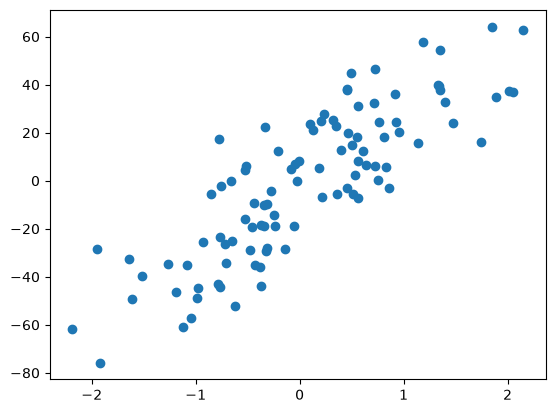

In [16]:
plt.scatter(X,Y)

In [17]:
reg = LinearRegression()
reg.fit(X,Y)
print(reg.coef_)
print(reg.intercept_)

[27.82809103]
-2.29474455867698


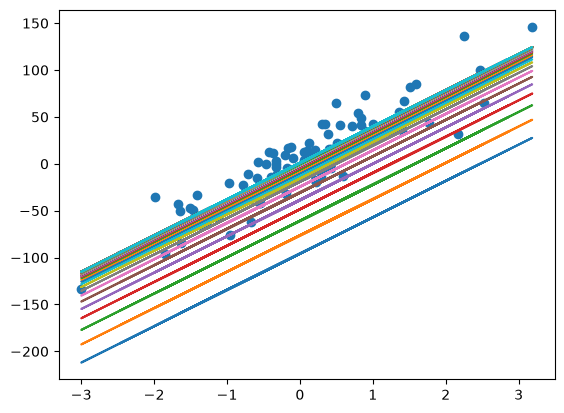

In [13]:
b = -120
m = 38.75
lr = 0.001
all_b = []
all_cost = []

epochs = 100

for i in range(epochs):
    slope = 0
    cost = 0
    for j in range(X.shape[0]):
        slope = slope - 2*(Y[j] - (m * X[j]) -  b)
        cost = cost + (Y[j] - m * X[j] -b) ** 2

    b = b - (lr * slope)
    all_b.append(b)
    all_cost.append(cost)
    Y_pred = m * X + b
    plt.plot(X,Y_pred)
plt.scatter(X,Y)

In [14]:
all_b = np.array(all_b).ravel()

In [15]:
all_b

array([-95.79806159, -76.43651087, -60.94727028, -48.55587782,
       -38.64276385, -30.71227267, -24.36787973, -19.29236537,
       -15.23195389, -11.98362471,  -9.38496136,  -7.30603068,
        -5.64288613,  -4.3123705 ,  -3.24795799,  -2.39642798,
        -1.71520398,  -1.17022478,  -0.73424141,  -0.38545472,
        -0.10642537,   0.11679811,   0.2953769 ,   0.43823993,
         0.55253035,   0.64396269,   0.71710856,   0.77562525,
         0.82243861,   0.8598893 ,   0.88984985,   0.91381828,
         0.93299304,   0.94833284,   0.96060468,   0.97042215,
         0.97827613,   0.98455931,   0.98958586,   0.99360709,
         0.99682408,   0.99939767,   1.00145655,   1.00310365,
         1.00442132,   1.00547547,   1.00631878,   1.00699343,
         1.00753315,   1.00796493,   1.00831035,   1.00858669,
         1.00880776,   1.00898462,   1.0091261 ,   1.00923929,
         1.00932984,   1.00940228,   1.00946023,   1.00950659,
         1.00954368,   1.00957335,   1.00959709,   1.00

In [16]:
all_cost = np.array(all_cost).ravel()
all_cost

array([1501806.14613344,  974645.70570029,  637263.02382307,
        421338.10742165,  283146.16092474,  194703.31516672,
        138099.89388159,  101873.7042591 ,   78688.94290071,
         63850.69563134,   54354.21737894,   48276.47129741,
         44386.71380523,   41897.26901023,   40304.02434143,
         39284.3477534 ,   38631.75473706,   38214.0952066 ,
         37946.79310711,   37775.71976344,   37666.23282348,
         37596.16118192,   37551.31533131,   37522.61398692,
         37504.24512652,   37492.48905586,   37484.96517063,
         37480.14988409,   37477.0681007 ,   37475.09575933,
         37473.83346086,   37473.02558983,   37472.50855238,
         37472.17764841,   37471.96586987,   37471.8303316 ,
         37471.74358711,   37471.68807063,   37471.65254009,
         37471.62980054,   37471.61524723,   37471.60593311,
         37471.59997208,   37471.59615701,   37471.59371537,
         37471.59215272,   37471.59115263,   37471.59051257,
         37471.59010293,

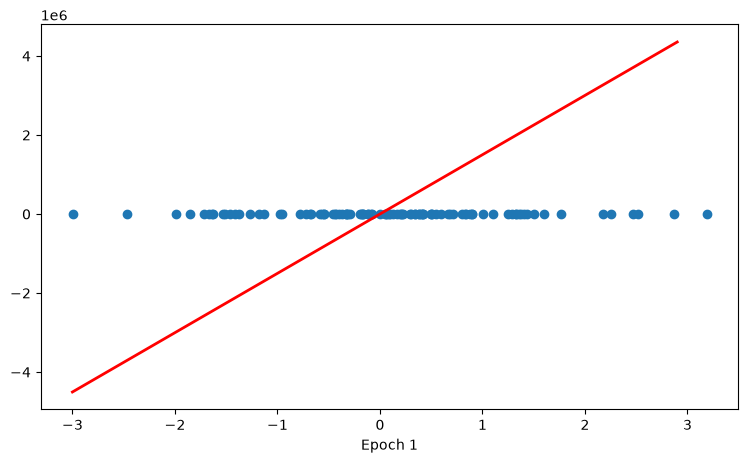

In [17]:
from IPython.display import HTML
fig, ax = plt.subplots(figsize=(9, 5))
x_i = np.arange(-3, 3, 0.1)
ax.scatter(X, Y)
# First epoch ki line
line, = ax.plot(x_i,x_i * all_cost[0] + all_b[0],'r-',linewidth=2)

def update(i):
    line.set_ydata(x_i * all_cost[i] + all_b[i])
    ax.set_xlabel(f'Epoch {i + 1}')
    return line,

anim = FuncAnimation(fig,update,frames=len(all_b),interval=500,repeat=True)
HTML(anim.to_jshtml())

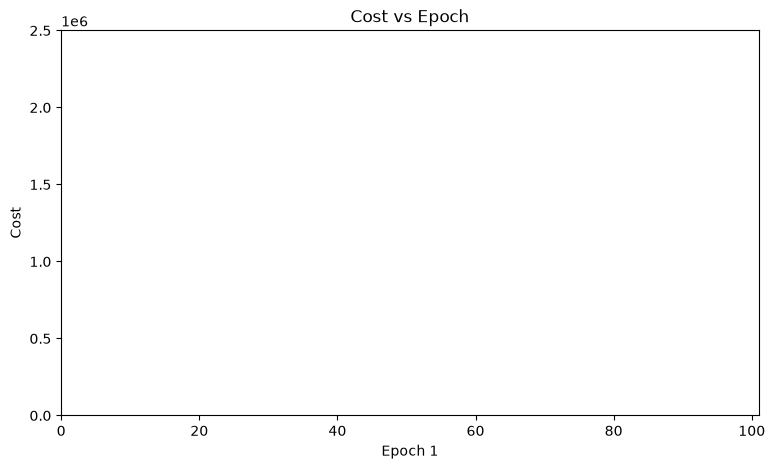

In [27]:
from IPython.display import HTML
import matplotlib.animation as animation
num_epochs = np.arange(1, 101)
fig = plt.figure(figsize=(9, 5))
axis = plt.axes(xlim=(0, 101),ylim=(0, 2500000))
line, = axis.plot([], [], lw=2)

def animate(i):
    line.set_data(num_epochs[:i+1],all_cost[:i+1])
    axis.set_xlabel(f'Epoch {i + 1}')
    axis.set_ylabel('Cost')
    axis.set_title('Cost vs Epoch')
    return line,
    
anim = animation.FuncAnimation(fig,animate,frames=100,repeat=False,interval=500)
HTML(anim.to_jshtml())